# <center>**06.1_train_CZC_baseline_model_example** </center>

### Table of Contents

1. **Notebook Overview**
   - Objective of Experiment 1: Binary classification of Calcific Tendinitis (CTRC).
   - Rationale for using a fine-tuned VGG19 architecture.
   - Integration of images from multiple workstations (CZC, RAD, MIN).
   - Strategy for model validation and generalizability.

2. **Environment Setup**
   - Import of core scientific libraries: `numpy`, `pandas`, `matplotlib`.
   - TensorFlow/Keras configuration for deep learning.
   - GPU memory management and verbosity control for clean execution.

3. **Data Loading & Subset Configuration**
   - Definition of training and test subsets from institutional databases.
   - Path management and verification of image-metadata consistency.
   - Dataset distribution analysis by acquisition workstation.
   - Implementation of **5-Fold Stratified Cross-Validation**.

4. **Custom Data Generation Pipeline**
   - Implementation of the `DataGenerator` class (Keras Sequence).
   - Rationale for batch-wise loading to manage high-volume medical imaging data.
   - Real-time preprocessing and synchronization of images and labels.

5. **CNN Model Architecture & Training Strategy**
   - Transfer Learning setup using the VGG19 backbone.
   - Custom classification head: Global Max Pooling (GMP) and Sigmoid activation.
   - Hyperparameter configuration and fine-tuning of convolutional layers.
   - Execution of the training loops across all validation folds.
   - Monitoring of accuracy and loss dynamics for training and validation sets.
   - Strategy for saving model weights and tracking convergence.

6. **Summary and Conclusions**
   - Insights into the impact of multi-workstation data on model performance.
   - Role of this trained CNN as a foundation for future hybrid ML experiments.

### **1. Notebook Overview**

This notebook implements the end-to-end training and optimization pipeline for a Convolutional Neural Network (CNN) aimed at the automated detection of Calcific Tendinitis of the Rotator Cuff (CTRC). The primary objective is to evaluate the diagnostic potential of Deep Learning on plain shoulder X-rays. The workflow encompasses every stage of model development, from multi-workstation data integration and advanced preprocessing to the execution of a fine-tuning strategy designed to achieve high diagnostic precision and robust generalizability.

A critical component of this pipeline is the implementation of a custom Data Generator class (inheriting from keras.utils.Sequence). Given the high volume of high-resolution medical images and the memory constraints of GPU training, this generator ensures efficient batch-wise loading and real-time preprocessing. It handles the synchronization between image paths and labels, applying necessary transformations while preventing memory overflow, which is essential for scaling the training process across the extensive dataset provided by "Institution 1".

The model architecture utilizes a VGG19 backbone pre-trained on ImageNet, adapted with a Global Max Pooling (GMP) layer and a sigmoid output for binary classification. The training is conducted using 5-fold Stratified Cross-Validation, ensuring that the balanced class distribution (50% CTRC, 50% healthy) is maintained across all folds. This methodology, combined with the fine-tuning of all convolutional layers, allows for a rigorous assessment of the model’s convergence and stability across different acquisition sources (CZC, RAD, and MIN workstations).

### **2. Environment Setup**

In [28]:
import os
import gc
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow import keras
try:
    _ = keras.__name__
except NameError:
    from tensorflow import keras

# 1. Configuración de variables de entorno antes de importar Keras
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
os.environ["AUTOGRAPH_VERBOSITY"] = "0"

# 2. Limpieza agresiva inicial
tf.keras.backend.clear_session()
gc.collect()

# 3. Control estricto de GPU
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        # Intentar limitar el uso de memoria para dejar espacio al sistema
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detectadas y configuradas: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error en configuración de GPU: {e}")

# 4. Función auxiliar para cargar datos sin saturar el kernel
def load_czc_metadata(base_path, subset_csv):
    path_csv = os.path.join(base_path, subset_csv)
    df = pd.read_csv(path_csv)
    
    # Construimos las rutas completas basándonos en el CSV, no en os.listdir
    # Esto es mucho más rápido y evita archivos ocultos del sistema
    subset_dir = os.path.join(base_path, subset_csv.replace('.csv', ''))
    
    df['full_path'] = df['rx_cod'].apply(lambda x: os.path.join(subset_dir, f"{x}.png")) # Ajusta extensión si es .jpg
    
    # Verificar solo los que existen físicamente
    df = df[df['full_path'].apply(os.path.exists)].reset_index(drop=True)
    
    return df['full_path'].values, df['label_CalTend'].values



GPUs detectadas y configuradas: 1


### **3. Data Loading & Subset Configuration**

In [11]:
# 1. Define subsets to load
subsets = ['TC_Canon_CZC_HURJC_train']

# 2. Experiment configuration
subsets_base_path = 'big_volume/Subsets/Subsets_main_dataset_cropped'

# 3. Initialize data containers
images_path = []
labels = []

# 4. Load data from defined subsets
for s in subsets:
    subset_dir = os.path.join(subsets_base_path, s)
    csv_path = os.path.join(subsets_base_path, f"{s}.csv")
    
    # Cargar metadatos
    df = pd.read_csv(csv_path)
    # Diccionario: clave = ID original, valor = Etiqueta
    label_dict = dict(zip(df['rx_cod'], df['label_CalTend']))
    
    # Listar imágenes en la carpeta
    all_files = [f for f in os.listdir(subset_dir) if f.lower().endswith(('.npy', '.jpg', '.jpeg', '.png'))]
    
    for f in all_files:
        # 1. Quitar extensión: 'Episodio01365_I_RE_cropped.npy' -> 'Episodio01365_I_RE_cropped'
        name_no_ext = os.path.splitext(f)[0]
        
        # 2. Quitar el sufijo '_cropped': 'Episodio01365_I_RE_cropped' -> 'Episodio01365_I_RE'
        # Usamos rsplit para asegurar que solo quitamos el último '_cropped'
        clean_id = name_no_ext.rsplit('_cropped', 1)[0]
        
        # 3. Emparejar con el CSV
        if clean_id in label_dict:
            images_path.append(os.path.join(subset_dir, f))
            labels.append(label_dict[clean_id])
        else:
            # Opcional: imprimir si algo sigue sin cuadrar
            print(f"Advertencia: No se encontró etiqueta para {clean_id} (archivo: {f})")

# 5. Convert to NumPy arrays
images_path = np.array(images_path)
y = np.array(labels)

# 6. Summary output
print(f"Total Images loaded: {len(images_path)}")
print(f"Labels shape: {y.shape}")


Total Images loaded: 1740
Labels shape: (1740,)


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

# === Stratified splitting of training dataset for k-fold cross validation ===

def stratified_split_lists(X_paths, y_labels, n_folds):
    """
    Manually splits a dataset into n_folds while maintaining class proportions.
    Returns a list of tuples containing (paths, labels) for each fold.
    """
    X_paths = np.array(X_paths)
    y_labels = np.array(y_labels) # Ensure labels are numpy array for stratification
    
    fold_array_size = len(X_paths) // n_folds
    arrays_list = []

    for i in range(n_folds - 1):
        # Split a chunk of 'fold_array_size' from the current data
        X_nfold, X_hold_out, y_nfold, y_hold_out = train_test_split(
            X_paths, 
            y_labels,
            train_size=fold_array_size,
            stratify=y_labels, 
            random_state=42
        )
        
        # Store the fold as a tuple of lists
        arrays = (X_nfold.tolist(), y_nfold.tolist())
        arrays_list.append(arrays)

        # Update the remaining data for the next iteration
        X_paths = X_hold_out
        y_labels = y_hold_out

    # Add the final remaining chunk as the last fold
    arrays = (X_paths.tolist(), y_labels.tolist())
    arrays_list.append(arrays)

    return arrays_list

# === Execute Stratified Splitting ===
# Split the matched CZC images (1740 samples) into 5 folds
X_y_folds = stratified_split_lists(X_paths=images_path, y_labels=y, n_folds=5)

# === Summary Verification ===
print(f"Total folds created: {len(X_y_folds)}")
for i, (f_x, f_y) in enumerate(X_y_folds):
    print(f"Fold {i+1}: {len(f_x)} samples - Distribution: {dict(Counter(f_y))}")

Total folds created: 5
Fold 1: 348 samples - Distribution: {0: 173, 1: 175}
Fold 2: 348 samples - Distribution: {1: 175, 0: 173}
Fold 3: 348 samples - Distribution: {1: 175, 0: 173}
Fold 4: 348 samples - Distribution: {0: 174, 1: 174}
Fold 5: 348 samples - Distribution: {1: 175, 0: 173}


### **4. Custom Data Generation Pipeline**

In [14]:
# Data Generator from Keras Sequence

from tensorflow.keras.utils import Sequence, to_categorical

class DataGenerator(Sequence):


    def __init__(self, image_paths, labels, batch_size, img_size, shuffle=True, seed=42):

        """
        Initialization
        
        Parameters:
        -----------
        image_paths : list
            List of image paths
        labels : array-like
            Array of integer labels (e.g., 0, 1, 2, ...).
        batch_size : int
            Size of the batch.
        img_size : tuple
            Image size (height, weight).
        shuffle : bool, optional
            Shuffle after each epoch.
        seed : int, optional
            Random seed.
        """
        self.image_paths = image_paths
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.img_size = img_size
        
        self.n_classes = len(np.unique(self.labels))
        if self.n_classes == 2:
            self.n_classes = 1
            
        self.shuffle = shuffle
        self.seed = seed
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()


    
    def __len__(self):
        # Number of batches per epoch
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    
    def __getitem__(self, index):
        
        # Generating indices for the current epoch
        start = index * self.batch_size
        end = (index + 1) * self.batch_size
        batch_indexes = self.indexes[start:end]

        # Batch creation
        batch_image_paths = [self.image_paths[i] for i in batch_indexes]
        batch_labels = [self.labels[i] for i in batch_indexes]
        
        X, y = self.__data_generation(batch_image_paths, batch_labels)
        
        return X, y

    
    def on_epoch_end(self):
        # Shuffle indexes after each epoch
        if self.shuffle:
            np.random.seed(self.seed)
            np.random.shuffle(self.indexes)

            
    def __data_generation(self, batch_image_paths, batch_labels):
        
        # Initialize arrays to store batch data
        X = np.empty((len(batch_image_paths), self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        y = np.empty((len(batch_image_paths),), dtype=int)
    
        # Iterate over each .npy image in the batch
        for i, path in enumerate(batch_image_paths):
            # Load preprocessed image from .npy file
            X_ = np.load(path)
            X[i] = X_
            y[i] = batch_labels[i]
    
        # Convert labels to one-hot encoding if there is more than two classes
        if self.n_classes > 2:
            y = to_categorical(y, num_classes=self.n_classes)
            
        return X, y
        

### **5. CNN Model Architecture & Training Strategy**

In [15]:
# Training class

class My_Custom_Model:


    def __init__ (self, train_gen, val_gen, img_size,
                  model_conv, freeze, top_m, neurons_last_layer, initializer_seed, optimizer, lr, loss_function, activation, metrics,
                  patience, batch_size, epochs, model_dir, model_fold, print_report, subset):

        self.train_gen = train_gen
        self.val_gen = val_gen
        self.img_size = img_size
        self.model_conv = model_conv
        self.freeze = freeze
        self.top_m = top_m
        self.neurons_last_layer = neurons_last_layer
        self.initializer_seed = initializer_seed
        self.optimizer = optimizer
        self.lr = lr
        self.lossf= loss_function
        self.activation = activation
        self.metrics= metrics
        self.patience= patience
        self.batch_size= batch_size
        self.epochs= epochs
        self.model_dir = model_dir
        self.model_fold = model_fold
        self.print_report= print_report
        self.subset = subset

        self.model_path = ('model_conv_' + str(model_conv) + '_freeze_' + str(freeze) + '_top_m_' + str(top_m) +
                           '_neurons_last_layer_' + str(neurons_last_layer) + '_optimizer_' + str(optimizer) +
                           '_loss_function_' + str(loss_function) + '_activation_' + str(activation[0]) +
                           '_initializer_seed_' + str(initializer_seed) + '_lr_' + str(lr) +
                           '_epochs_' + str(epochs) + '_batch_size_' + str(batch_size) + '_patience_' + str(patience) +
                           '_subset_' + str(subset))

        self.model_dir_model_path_model_fold = os.path.join(self.model_dir, self.model_path, 'FOLD_' + str(self.model_fold))

        if os.path.exists(self.model_dir_model_path_model_fold):
            print(f'[WARNING] self.model_dir_model_path_model_fold {self.model_dir_model_path_model_fold} already exists')
            raise SystemExit  # O usa `sys.exit()` si prefieres
        else:
            os.makedirs(self.model_dir_model_path_model_fold)


    def base_model_tuning (self):
        # Importing the model and freezing/unfreezing layers
        # freeze True would freeze all the layers, freeze False would unfreeze all layers
        # and freeze int would freeze layers from 0 up to (but not including) that int

        if self.model_conv == 'IV3':
             self.base_model= keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'VGG16':
             self.base_model = keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'VGG19':
             self.base_model = keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet50':
             self.base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet101':
             self.base_model = keras.applications.ResNet101(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet152':
             self.base_model = keras.applications.ResNet152(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet50V2':
             self.base_model = keras.applications.ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet101V2':
             self.base_model = keras.applications.ResNet101V2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'ResNet152V2':
             self.base_model = keras.applications.ResNet152V2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'Xception':
             self.base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'InceptionResNetV2':
            self.base_model = keras.applications.InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'DenseNet121':
            self.base_model = keras.applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'DenseNet169':
            self.base_model = keras.applications.DenseNet169(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'DenseNet201':
            self.base_model = keras.applications.DenseNet201(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'MobileNet':
            self.base_model = keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'MobileNetV2':
            self.base_model = keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'NASNetMobile':
            self.base_model = keras.applications.NASNetMobile(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'NASNetLarge':
            self.base_model = keras.applications.NASNetLarge(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB0':
            self.base_model = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB1':
            self.base_model = keras.applications.EfficientNetB1(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB2':
            self.base_model = keras.applications.EfficientNetB2(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB3':
            self.base_model = keras.applications.EfficientNetB3(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB4':
            self.base_model = keras.applications.EfficientNetB4(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB5':
            self.base_model = keras.applications.EfficientNetB5(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB6':
            self.base_model = keras.applications.EfficientNetB6(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
        elif self.model_conv == 'EfficientNetB7':
            self.base_model = keras.applications.EfficientNetB7(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

        
        if self.freeze == False:
             for layer in self.base_model.layers:
                    layer.trainable = True
             #print('None of the layers frozen')

        elif self.freeze == True:
            for layer in self.base_model.layers:
                layer.trainable = False
            #print ('All layers frozen')
        
        else:
             num_layers = len(self.base_model.layers)
             unfreeze_count = math.ceil(num_layers * self.freeze)
             unfreeze_from = num_layers - unfreeze_count
            
             for layer in model.layers[:unfreeze_from]:
                 layer.trainable = False
                 #print('Layer ' + layer.name + ' frozen...')
            
             for layer in model.layers[unfreeze_from:]:
                 layer.trainable = True
                 #print('Layer ' + layer.name + ' not frozen...')


    def model_top_setting (self):
        # Definition of the model_top, review the architectures of the classifiers before each test

        initializer_1 = tf.keras.initializers.he_normal(seed=self.initializer_seed)
        initializer_2 = tf.keras.initializers.GlorotNormal(seed=self.initializer_seed)

        if self.top_m == 'GMP':
             self.model_top = keras.models.Sequential()
             self.model_top.add (self.base_model)
             self.model_top.add (keras.layers.GlobalMaxPooling2D())
        if self.top_m == 'GAP':
             self.model_top = keras.models.Sequential()
             self.model_top.add (self.base_model)
             self.model_top.add (keras.layers.GlobalAveragePooling2D())
        if self.top_m == 'FD':
             self.model_top = keras.models.Sequential()
             self.model_top.add (self.base_model)
             self.model_top.add (keras.layers.Flatten())
             self.model_top.add (keras.layers.Dense(128, activation='relu', kernel_initializer=initializer_1))
             self.model_top.add (keras.layers.Dense(64, activation='relu', kernel_initializer=initializer_1))

        if self.top_m == 'GMP + Dropout':
            self.model_top = keras.models.Sequential()
            self.model_top.add (self.base_model)
            self.model_top.add (keras.layers.GlobalMaxPooling2D())
            self.model_top.add(keras.layers.Dropout(0.2))
            self.model_top.add (keras.layers.Dense(256, activation='relu', kernel_initializer=initializer_1))
            self.model_top.add(keras.layers.Dropout(0.2))

        if self.top_m == 'FD + 2 capas':
            self.model_top = keras.models.Sequential()
            self.model_top.add (self.base_model)
            self.model_top.add (keras.layers.Flatten())
            self.model_top.add (keras.layers.Dense(256, activation='relu', kernel_initializer=initializer_1))
            self.model_top.add (keras.layers.Dense(64, activation='relu', kernel_initializer=initializer_1))

        if self.neurons_last_layer == 1:
             self.model_top.add (keras.layers.Dense(self.neurons_last_layer, activation='sigmoid', kernel_initializer=initializer_2))
             if self.lossf == 'categorical_crossentropy':
                 print(f'Categorical_crossentropy changed for binary_crossentropy')
                 self.lossf == 'binary_crossentropy'
        
        if self.neurons_last_layer > 1:
             self.model_top.add (keras.layers.Dense(self.neurons_last_layer, activation=self.activation, kernel_initializer=initializer_2))
             if self.lossf == 'binary_crossentropy' and self.activation == 'softmax':
                 print(f'Binary_crossentropy changed for categorical_crossentropy')
                 self.lossf == 'categorical_crossentropy'
        
        return self.model_top


    def model_compilation (self):
        # Model compilation

        if self.optimizer == 'SGD':
            self.opt= keras.optimizers.SGD (learning_rate= self.lr)
        elif self.optimizer == 'RMSprop':
            self.opt= keras.optimizers.RMSprop (learning_rate= self.lr)
        elif self.optimizer == 'ADAM':
            self.opt= keras.optimizers.Adam (learning_rate= self.lr, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
        elif self.optimizer == 'ADADELTA':
            self.opt= keras.optimizers.Adadelta (learning_rate= self.lr)
        elif self.optimizer == 'ADAGRAD':
            self.opt= keras.optimizers.Adagrad (learning_rate= self.lr)
        elif self.optimizer == 'ADAMAX':
            self.opt= keras.optimizers.ADAMAX (learning_rate= self.lr)
        elif self.optimizer == 'NADAM':
            self.opt= keras.optimizers.Nadam (learning_rate= self.lr)
        elif self.optimizer == 'FTRL':
            self.opt= keras.optimizers.Ftrl (learning_rate= self.lr)

        self.model= self.model_top
        self.model.compile (optimizer=self.opt, loss=self.lossf, metrics= self.metrics)

        return self.model   


    def model_fit(self):
        
        # Training model
        best_model_path = os.path.join(self.model_dir_model_path_model_fold, 'best_model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}_val_acc_{val_accuracy:.4f}.h5')
        
        checkpoint1 = keras.callbacks.ModelCheckpoint(best_model_path, save_best_only=True, monitor='val_loss')
        checkpoint2 = keras.callbacks.ModelCheckpoint(best_model_path, save_best_only=True, monitor='val_accuracy')
        early_stop  = keras.callbacks.EarlyStopping(patience=patience, restore_best_weights=True)

        self.history = self.model.fit(self.train_gen,
                                      validation_data=self.val_gen,
                                      epochs=self.epochs,
                                      callbacks=[checkpoint1, checkpoint2, early_stop],
                                      workers=4,
                                      use_multiprocessing=True,
                                      verbose=1)
        
        history_path =     os.path.join(self.model_dir_model_path_model_fold, 'history.npy')
        final_model_path = os.path.join(self.model_dir_model_path_model_fold, 'final_model.h5')
        
        np.save(history_path, self.history.history)
        self.model.save(final_model_path)

    
    def training_loss_curves (self):
        # Plottin loss curves

        self.loss_train = self.history.history['loss']
        self.loss_val = self.history.history['val_loss']

        self.epochs = range(0,len(self.history.history['val_loss']))

        self.loss_curve = plt.figure(dpi=300, facecolor='w', edgecolor='w', frameon=True)
        plt.plot(self.epochs, self.loss_train, 'g', label='Training loss')
        plt.plot(self.epochs, self.loss_val, 'b', label='Validation loss')
        plt.title('Training and Validation loss curves')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend(loc='upper right')
        loss_curve_path = os.path.join(self.model_dir_model_path_model_fold, f'LOSS_CURVE_{self.subset}.png')
        #loss_curve_path = os.path.join(self.model_dir_model_path_model_fold, ('LOSS_CURVE_' + 'model_' + self.model_path + '.png'))
        self.loss_curve.savefig(loss_curve_path)


    def training_accuracy_curves (self):
        # Plotting accuracy curves

        self.acc_train = self.history.history['accuracy']
        self.acc_val = self.history.history['val_accuracy']

        self.epochs = range(0,len(self.history.history['val_accuracy']))

        self.acc_curve = plt.figure(dpi=300, facecolor='w', edgecolor='w', frameon=True)
        plt.plot(self.epochs, self.acc_train, 'g', label='Training accuracy')
        plt.plot(self.epochs, self.acc_val, 'b', label='Validation accuracy')
        plt.title('Training and Validation accuracy curves')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend(loc='upper left')
        acc_curve_path = os.path.join(self.model_dir_model_path_model_fold, f'ACCURACY_CURVE_{self.subset}.png')
        #acc_curve_path = os.path.join(self.model_dir_model_path_model_fold, ('ACCURACY_CURVE_' + 'model_' + self.model_path + '.png'))
        self.acc_curve.savefig(acc_curve_path)


    def generate_report (self):
        # Generate training report

        if print_report == True:
    
            df_params = pd.DataFrame ({'model_conv':    [self.model_conv],
                                       'layers_frozen': [self.freeze],
                                       'model_top': [self.optimizer],
                                       'lr': [self.lr],
                                       'model_n_layers': [self.neurons_last_layer],
                                       'loss_function': [self.lossf],
                                       'initializer_seed': [self.initializer_seed],
                                       'patience': [self.patience],
                                       'batch_size': [self.batch_size],
                                       'epochs': [self.epochs]})
            
            df_params.to_csv (os.path.join(self.model_dir_model_path_model_fold, self.subset + '_params.csv'))
            display(df_params)
            
            print('')

            print(self.model.summary(), '\n')
            print('TRAINING \n')


    def runall (self):

        self.base_model_tuning()
        self.model_top_setting()
        self.model_compilation()
        self.generate_report()
        self.model_fit()
        self.training_loss_curves()
        self.training_accuracy_curves()

        tf.keras.backend.clear_session() 
        gc.collect()
        

In [26]:
# Set hyperparams

subset = subset_name
k = 5
img_size = (300, 300)
metrics= ['accuracy']
model_dir =  os.path.join ('Models/', subset) 
print_report= True
hyperparameters_dict = {
    
    'Params': ['model_conv', 'freeze', 'top_m', 'neurons_last_layer', 'initializer_seed', 'optimizer',
                       'lr', 'loss_function', 'activation', 'patience', 'batch_size', 'epochs', 'Result'],
            

    'Config 0': ['VGG19',       False, 'GMP',           1, 42, 'SGD', 0.005, 'binary_crossentropy', 'sigmoid', 15, 32, 50, False]}

df_hyperparms = pd.DataFrame (hyperparameters_dict)
df_hyperparms = df_hyperparms.set_index('Params').T
df_hyperparms.to_csv (os.path.join(model_dir, 'df_hyperparms_' + subset + '.csv'))
df_hyperparms


Params,model_conv,freeze,top_m,neurons_last_layer,initializer_seed,optimizer,lr,loss_function,activation,patience,batch_size,epochs,Result
Config 0,VGG19,False,GMP,1,42,SGD,0.005,binary_crossentropy,sigmoid,15,32,50,False


STATIONS: train_CZC 

 ------------
|EXPERIMENT 1|
 ------------


FOLD 1
--------------



,model_conv,layers_frozen,model_top,lr,model_n_layers,loss_function,initializer_seed,patience,batch_size,epochs
0,VGG19,False,SGD,0.005,1,binary_crossentropy,42,15,32,50



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None 

TRAINING 

Epoch 1/50
44/44 [==============================] - ETA: 0s - loss: 0.7038 - accuracy: 0.5402

/home/ubuntu/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


44/44 [==============================] - 48s 1s/step - loss: 0.7038 - accuracy: 0.5402 - val_loss: 0.6725 - val_accuracy: 0.5862
Epoch 2/50
44/44 [==============================] - 47s 1s/step - loss: 0.6565 - accuracy: 0.6135 - val_loss: 0.6540 - val_accuracy: 0.6034
Epoch 3/50
44/44 [==============================] - 45s 1s/step - loss: 0.6334 - accuracy: 0.6458 - val_loss: 0.7244 - val_accuracy: 0.5345
Epoch 4/50
44/44 [==============================] - 47s 1s/step - loss: 0.5765 - accuracy: 0.6889 - val_loss: 0.5849 - val_accuracy: 0.7011
Epoch 5/50
44/44 [==============================] - 44s 986ms/step - loss: 0.5638 - accuracy: 0.6918 - val_loss: 0.5870 - val_accuracy: 0.6810
Epoch 6/50
44/44 [==============================] - 46s 1s/step - loss: 0.4996 - accuracy: 0.7543 - val_loss: 0.5553 - val_accuracy: 0.7011
Epoch 7/50
44/44 [==============================] - 48s 1s/step - loss: 0.4776 - accuracy: 0.7651 - val_loss: 0.5126 - val_accuracy: 0.7414
Epoch 8/50
44/44 [==========

...

44/44 [==============================] - 52s 1s/step - loss: 0.6958 - accuracy: 0.5560 - val_loss: 0.6611 - val_accuracy: 0.6034
Epoch 2/50
44/44 [==============================] - 47s 1s/step - loss: 0.6427 - accuracy: 0.6121 - val_loss: 0.6423 - val_accuracy: 0.6351
Epoch 3/50
44/44 [==============================] - 47s 1s/step - loss: 0.6123 - accuracy: 0.6652 - val_loss: 0.6014 - val_accuracy: 0.6724
Epoch 4/50
44/44 [==============================] - 45s 995ms/step - loss: 0.6263 - accuracy: 0.6444 - val_loss: 0.6694 - val_accuracy: 0.5632
Epoch 5/50
44/44 [==============================] - 47s 1s/step - loss: 0.5836 - accuracy: 0.6940 - val_loss: 0.6601 - val_accuracy: 0.5718
Epoch 6/50
44/44 [==============================] - 47s 1s/step - loss: 0.5004 - accuracy: 0.7371 - val_loss: 0.8523 - val_accuracy: 0.5287
Epoch 7/50
44/44 [==============================] - 50s 1s/step - loss: 0.4899 - accuracy: 0.7737 - val_loss: 0.5324 - val_accuracy: 0.7126
Epoch 8/50
44/44 [==========

,model_conv,layers_frozen,model_top,lr,model_n_layers,loss_function,initializer_seed,patience,batch_size,epochs
0,VGG19,False,SGD,0.005,1,binary_crossentropy,42,15,32,50



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 9, 9, 512)         20024384  
                                                                 
 global_max_pooling2d (Glob  (None, 512)               0         
 alMaxPooling2D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 513       
                                                                 
Total params: 20024897 (76.39 MB)
Trainable params: 20024897 (76.39 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None 

TRAINING 

Epoch 1/50
44/44 [==============================] - ETA: 0s - loss: 0.7171 - accuracy: 0.5216

/home/ubuntu/.local/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


44/44 [==============================] - 51s 1s/step - loss: 0.7171 - accuracy: 0.5216 - val_loss: 0.6808 - val_accuracy: 0.5747
Epoch 2/50
44/44 [==============================] - 49s 1s/step - loss: 0.6678 - accuracy: 0.5991 - val_loss: 0.6606 - val_accuracy: 0.5862
Epoch 3/50
44/44 [==============================] - 47s 1s/step - loss: 0.6299 - accuracy: 0.6473 - val_loss: 0.6487 - val_accuracy: 0.5862
Epoch 4/50
44/44 [==============================] - 49s 1s/step - loss: 0.5961 - accuracy: 0.6789 - val_loss: 0.6068 - val_accuracy: 0.6580
Epoch 5/50
44/44 [==============================] - 49s 1s/step - loss: 0.5766 - accuracy: 0.6932 - val_loss: 0.5875 - val_accuracy: 0.6782
Epoch 6/50
44/44 [==============================] - 46s 1s/step - loss: 0.5279 - accuracy: 0.7356 - val_loss: 0.6283 - val_accuracy: 0.6552
Epoch 7/50
44/44 [==============================] - 50s 1s/step - loss: 0.4747 - accuracy: 0.7579 - val_loss: 0.5256 - val_accuracy: 0.7299
Epoch 8/50
44/44 [=============

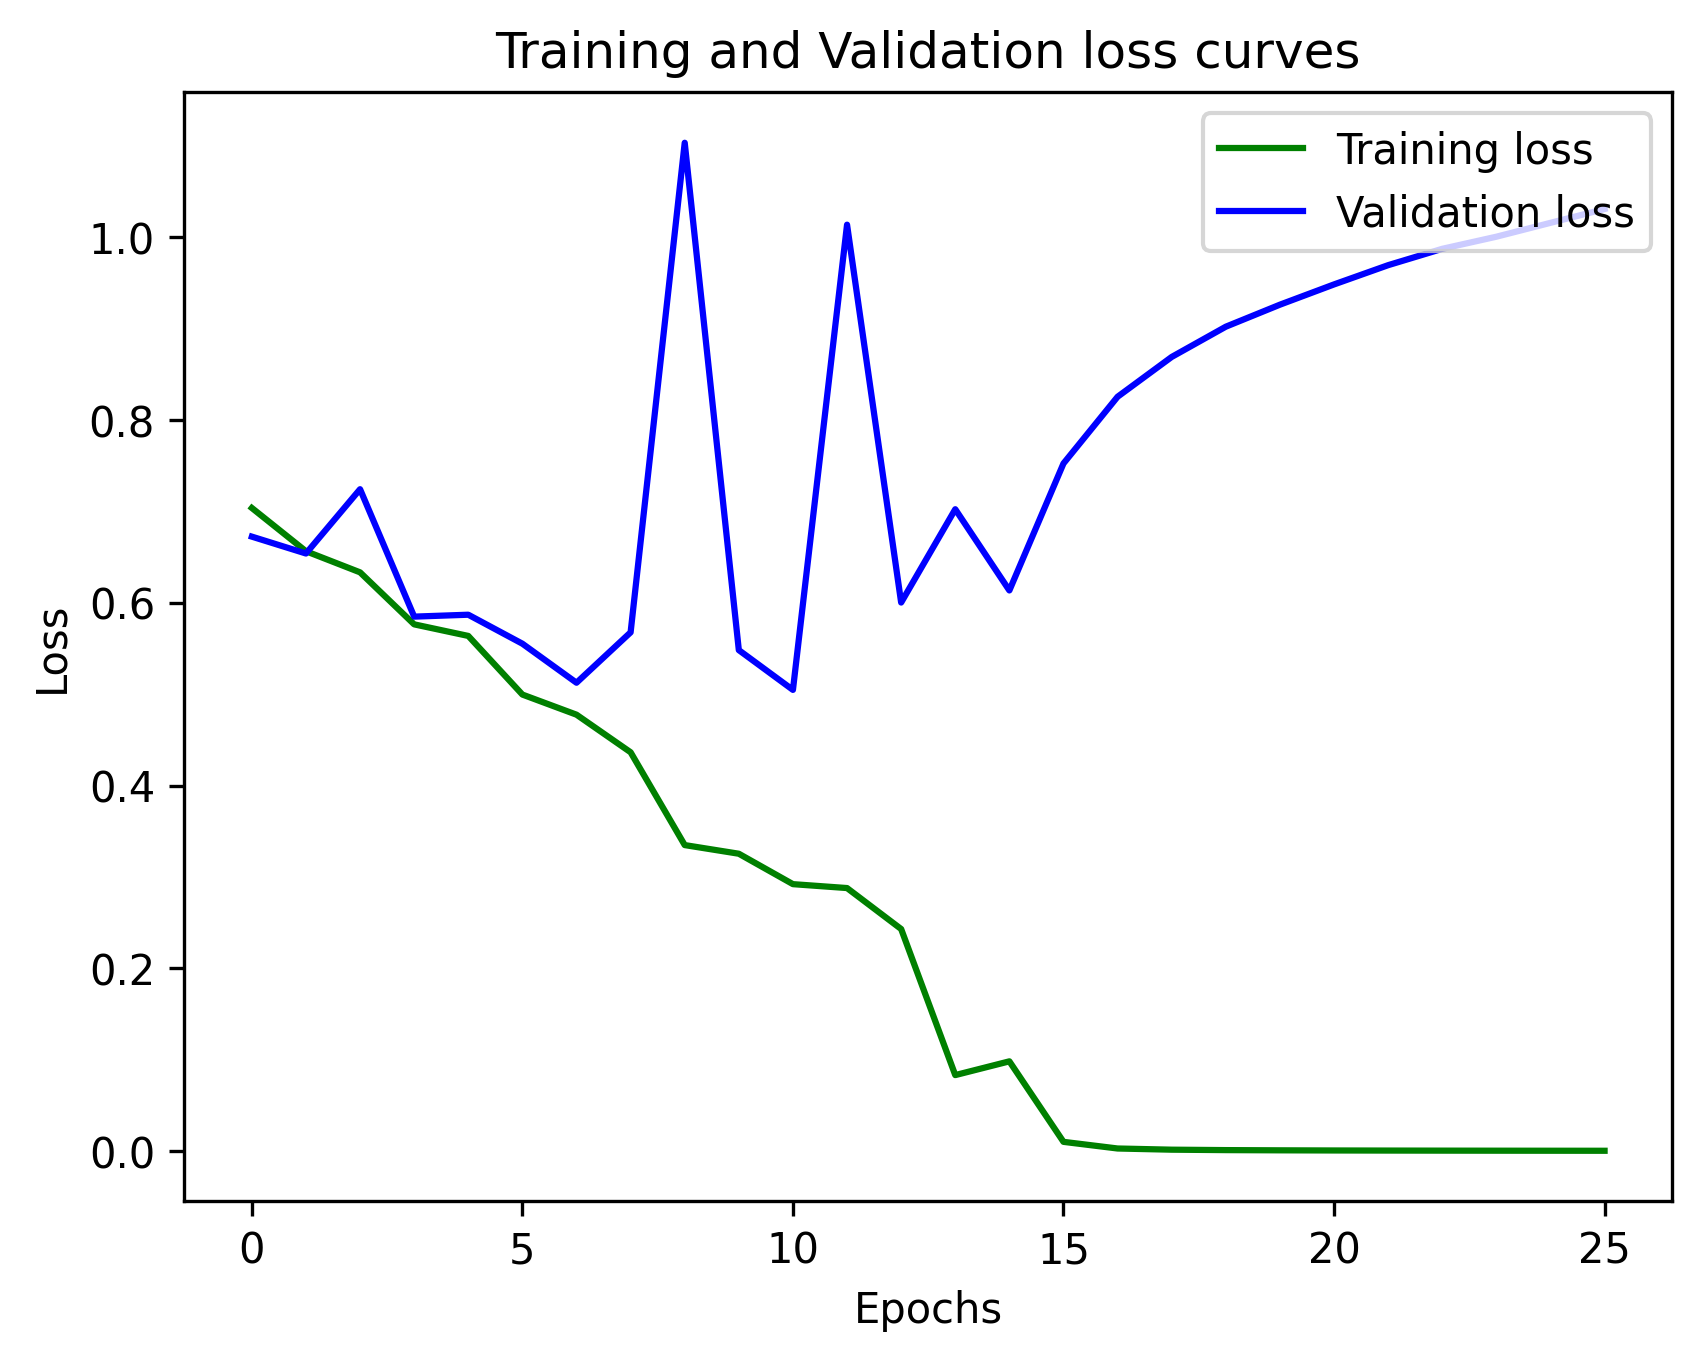

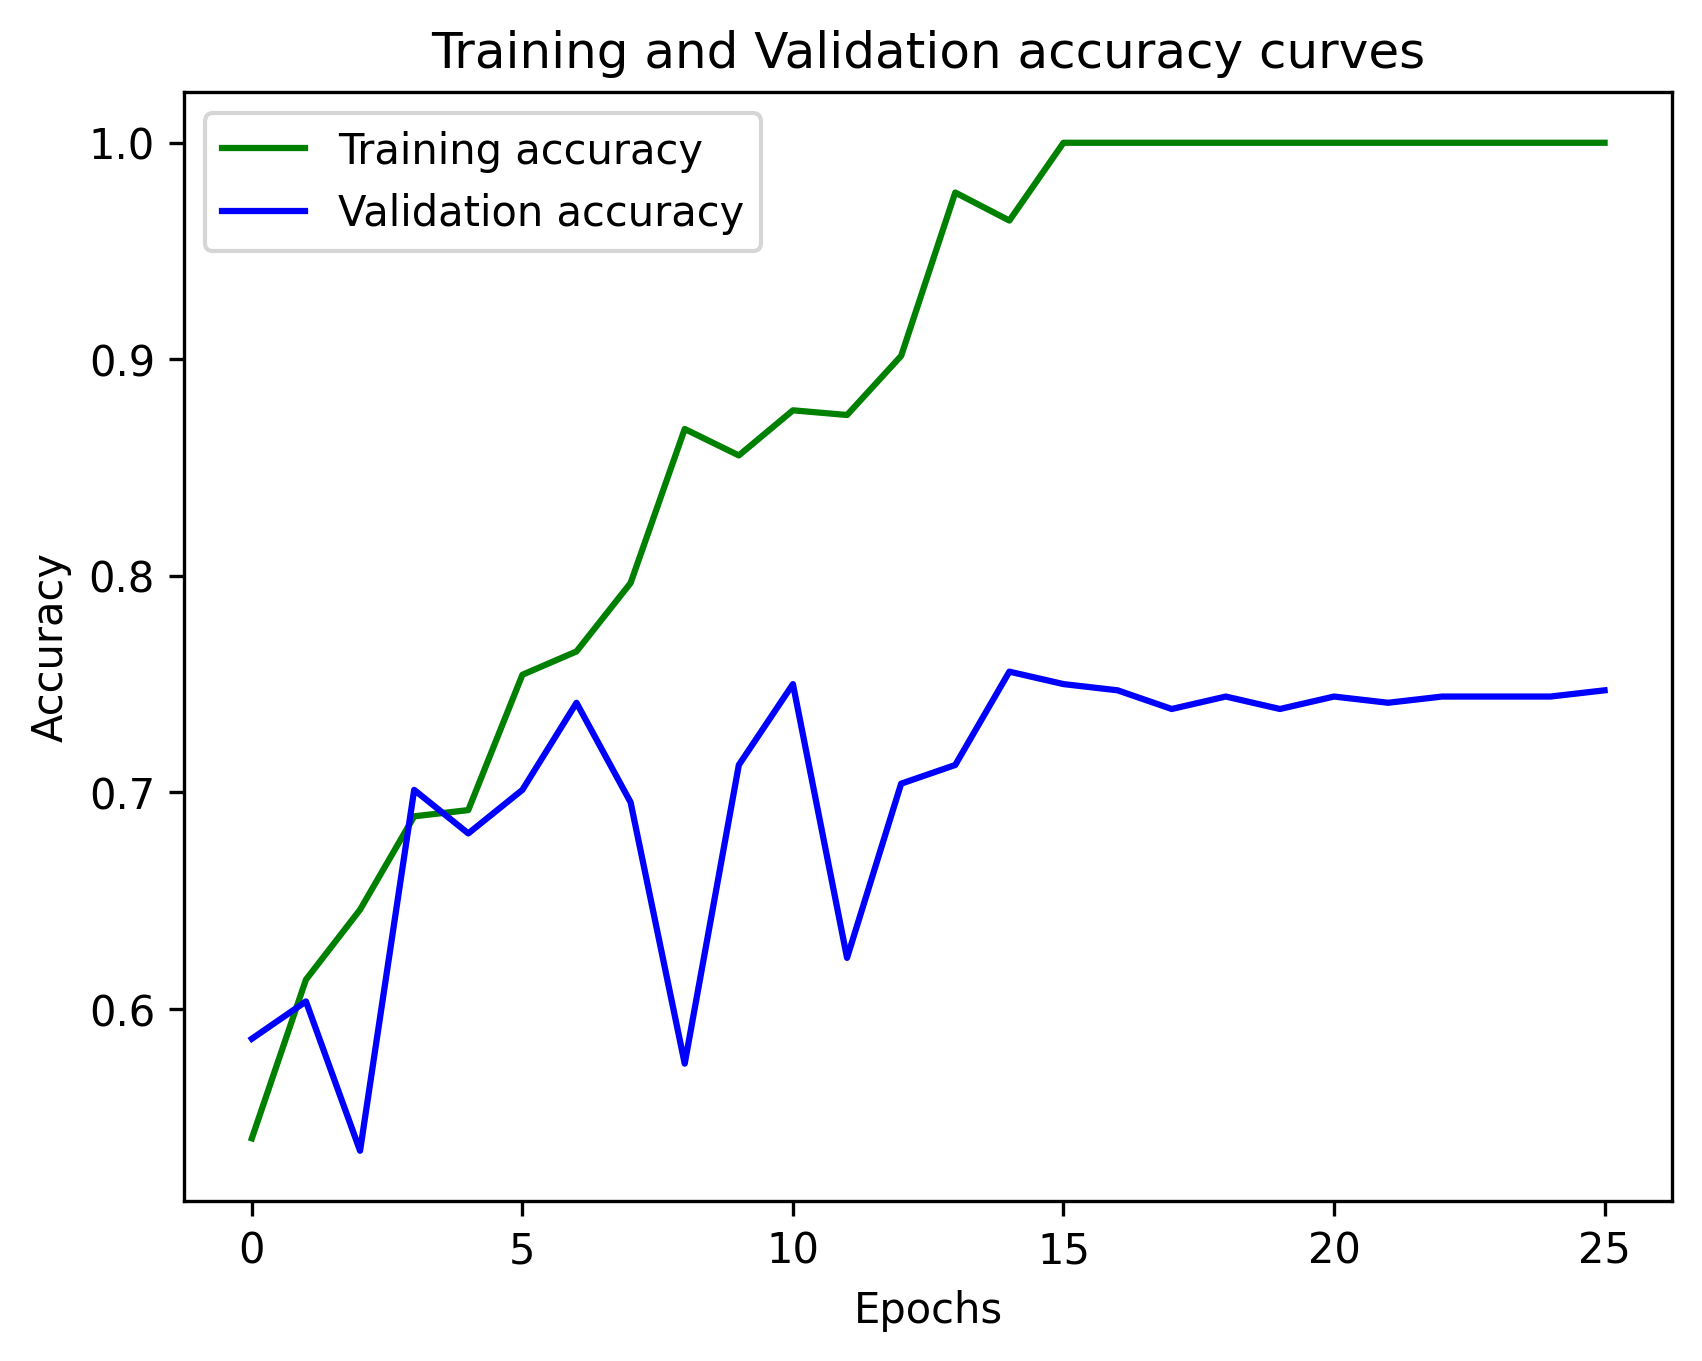

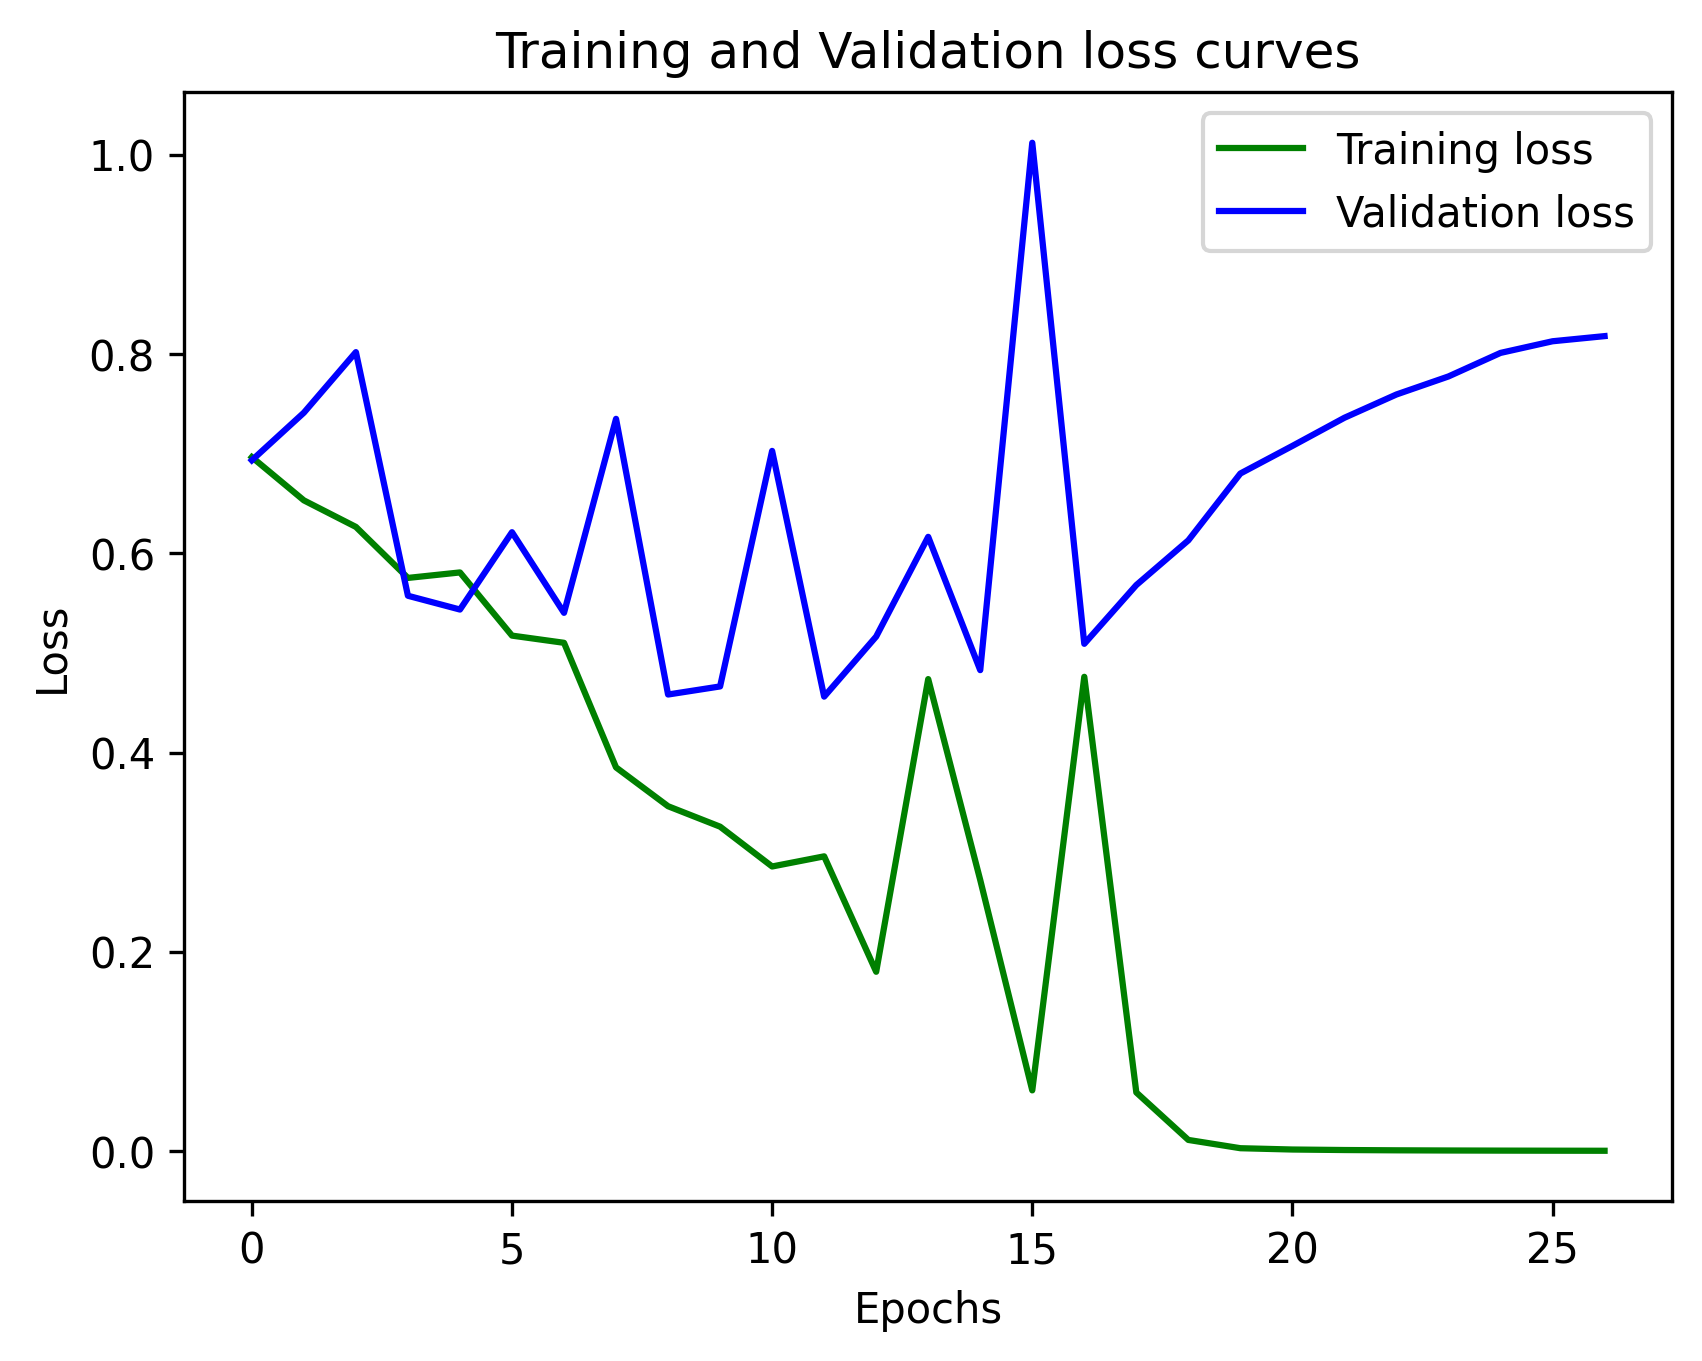

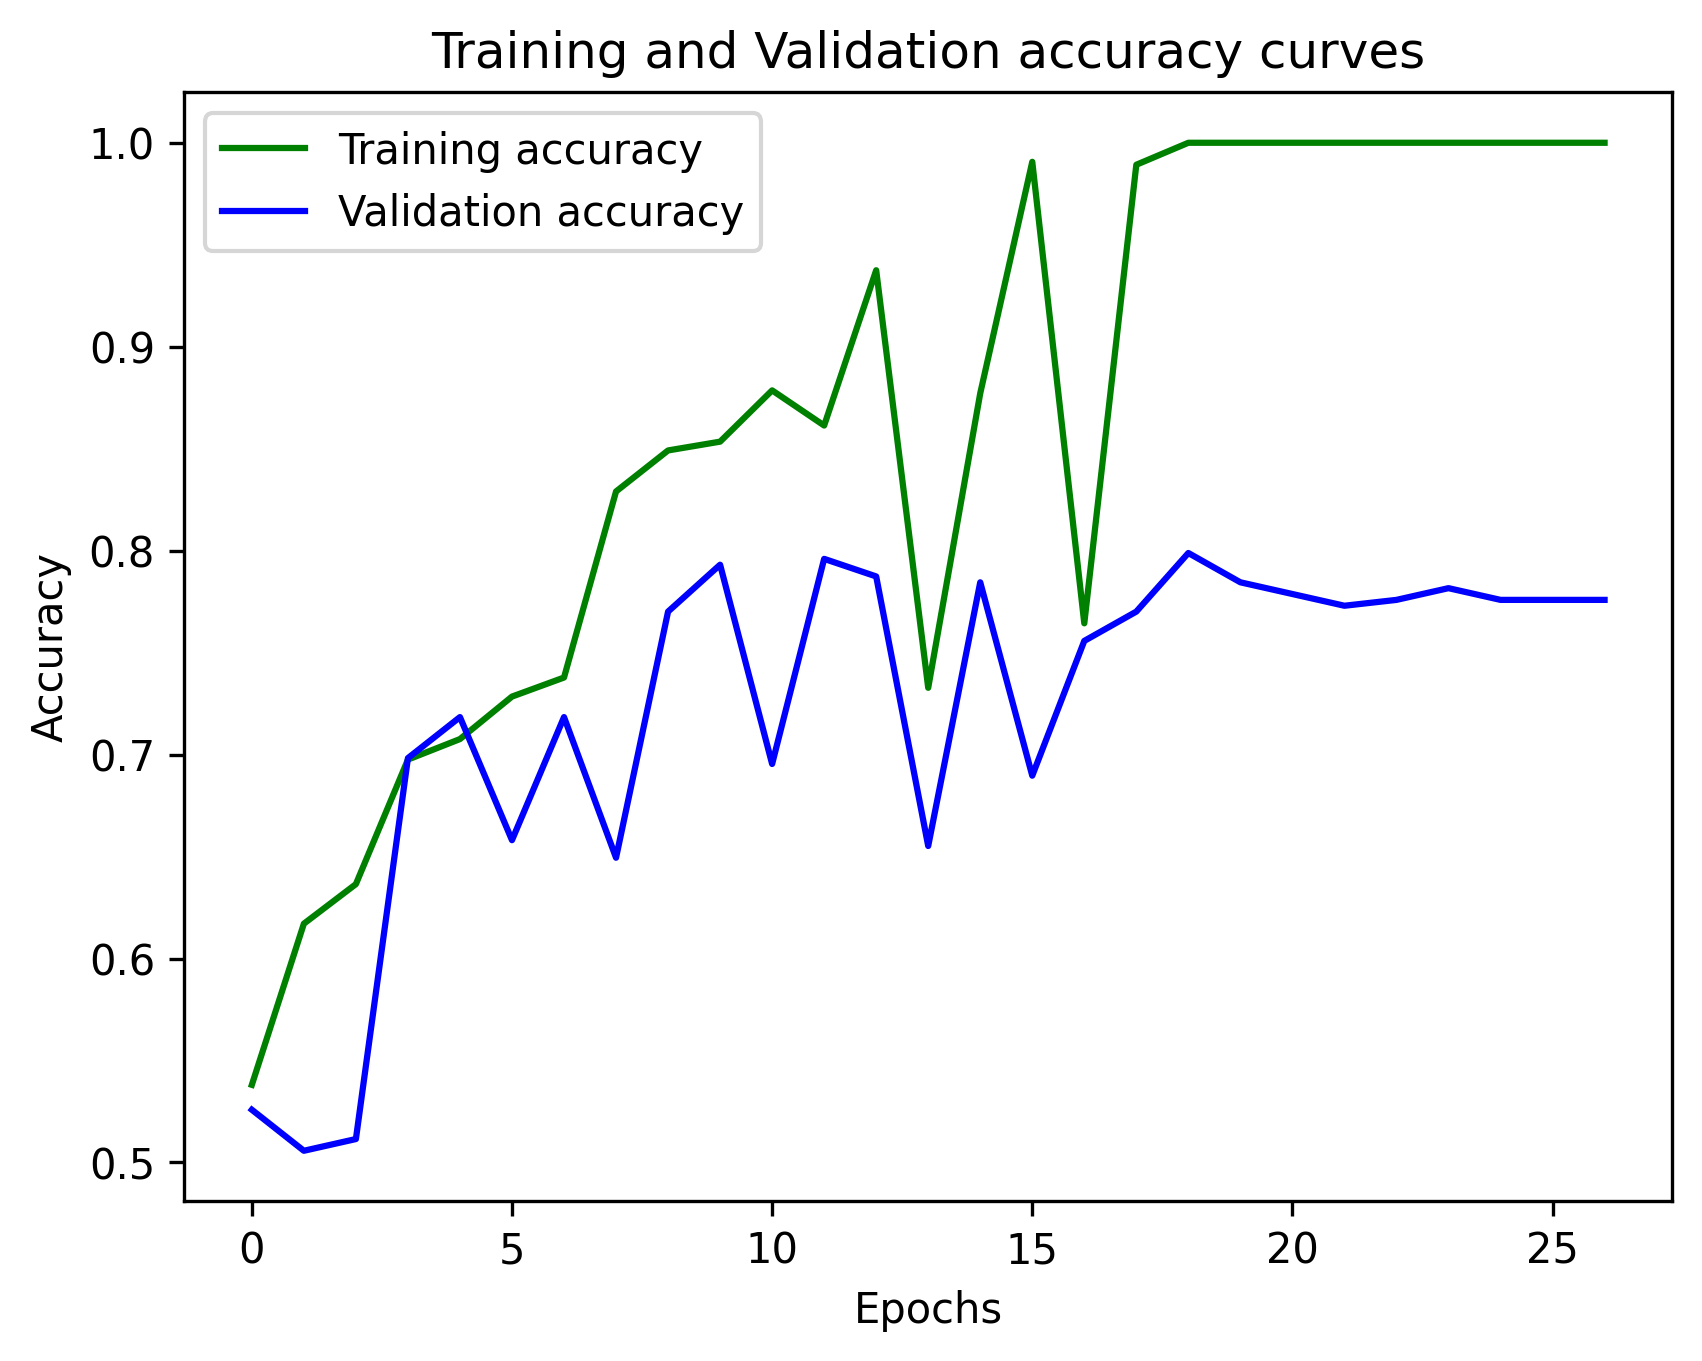

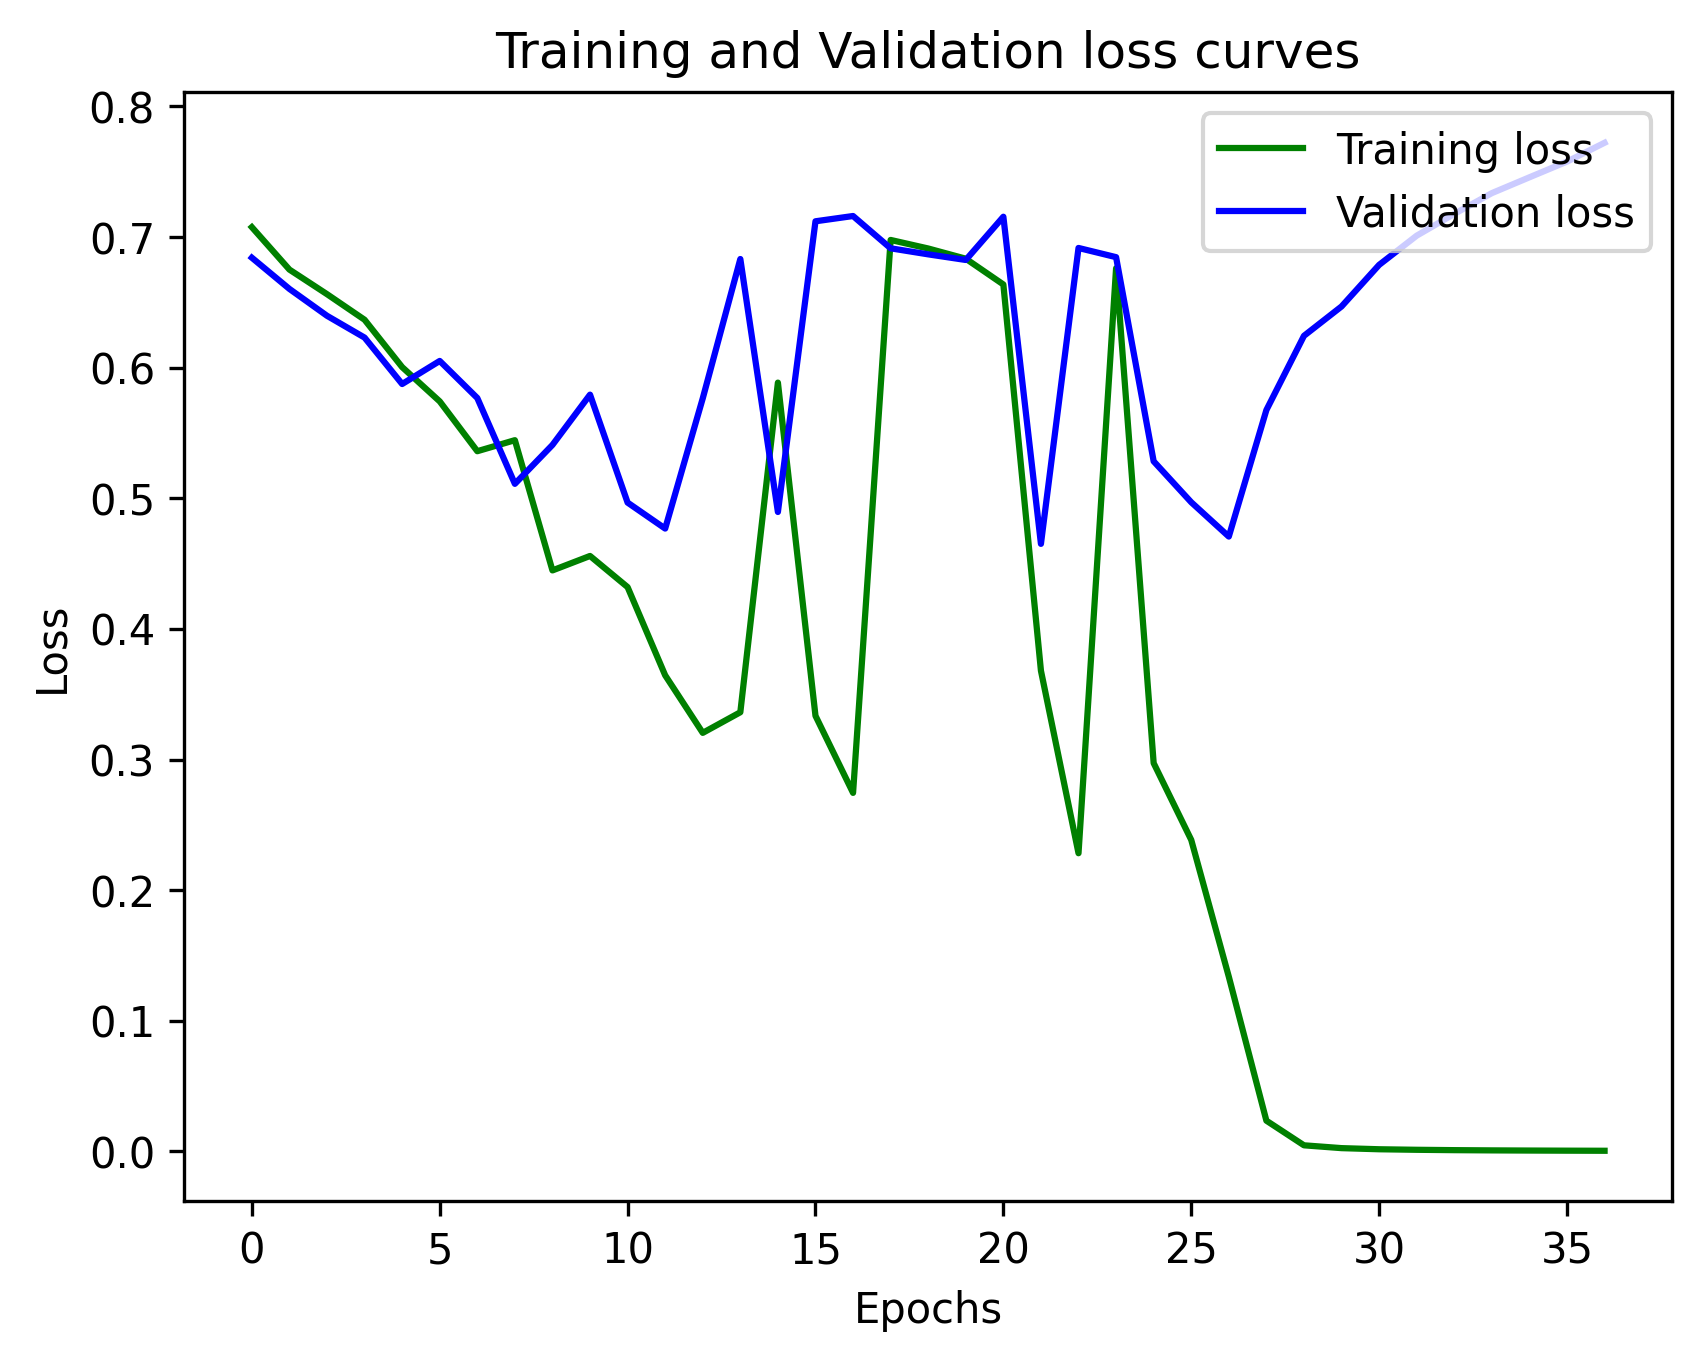

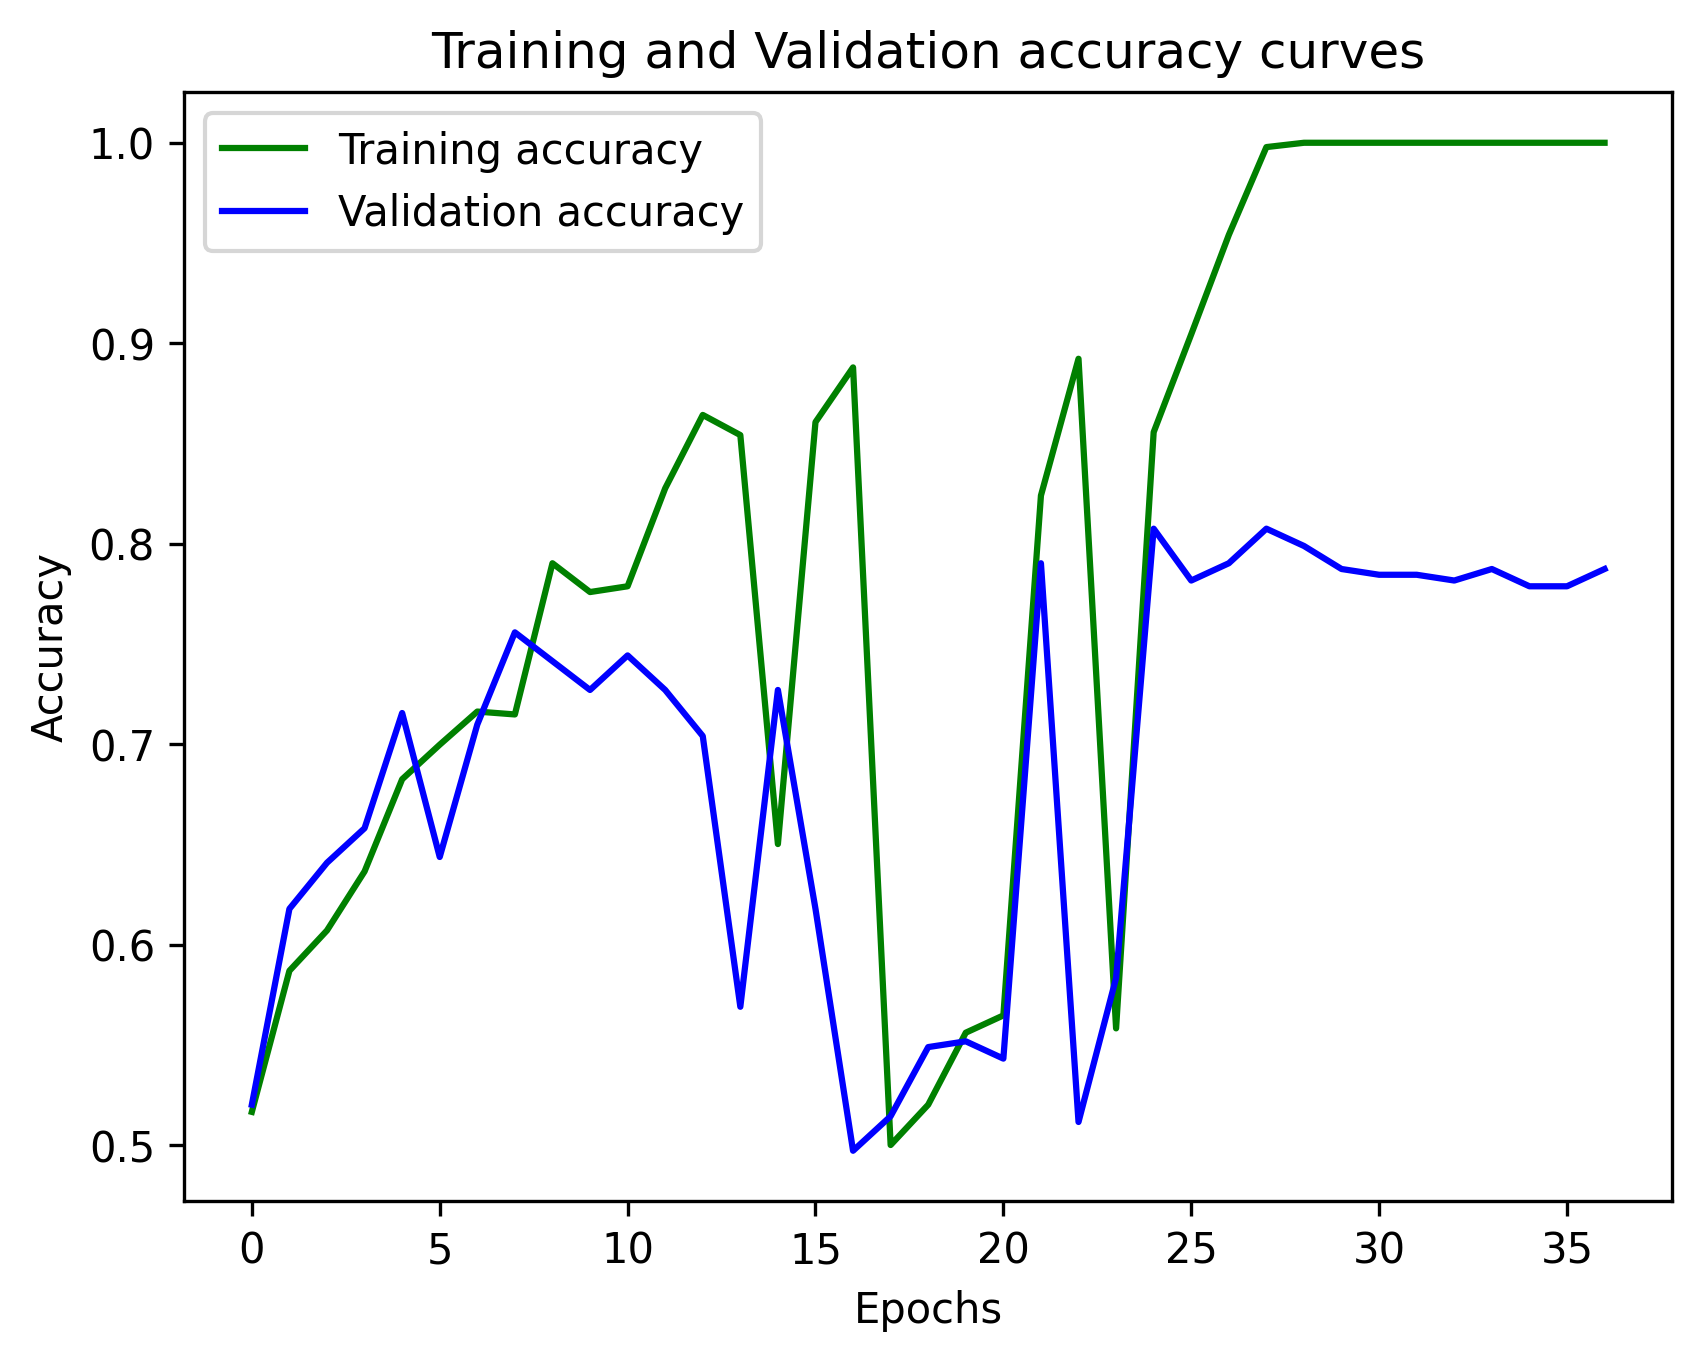

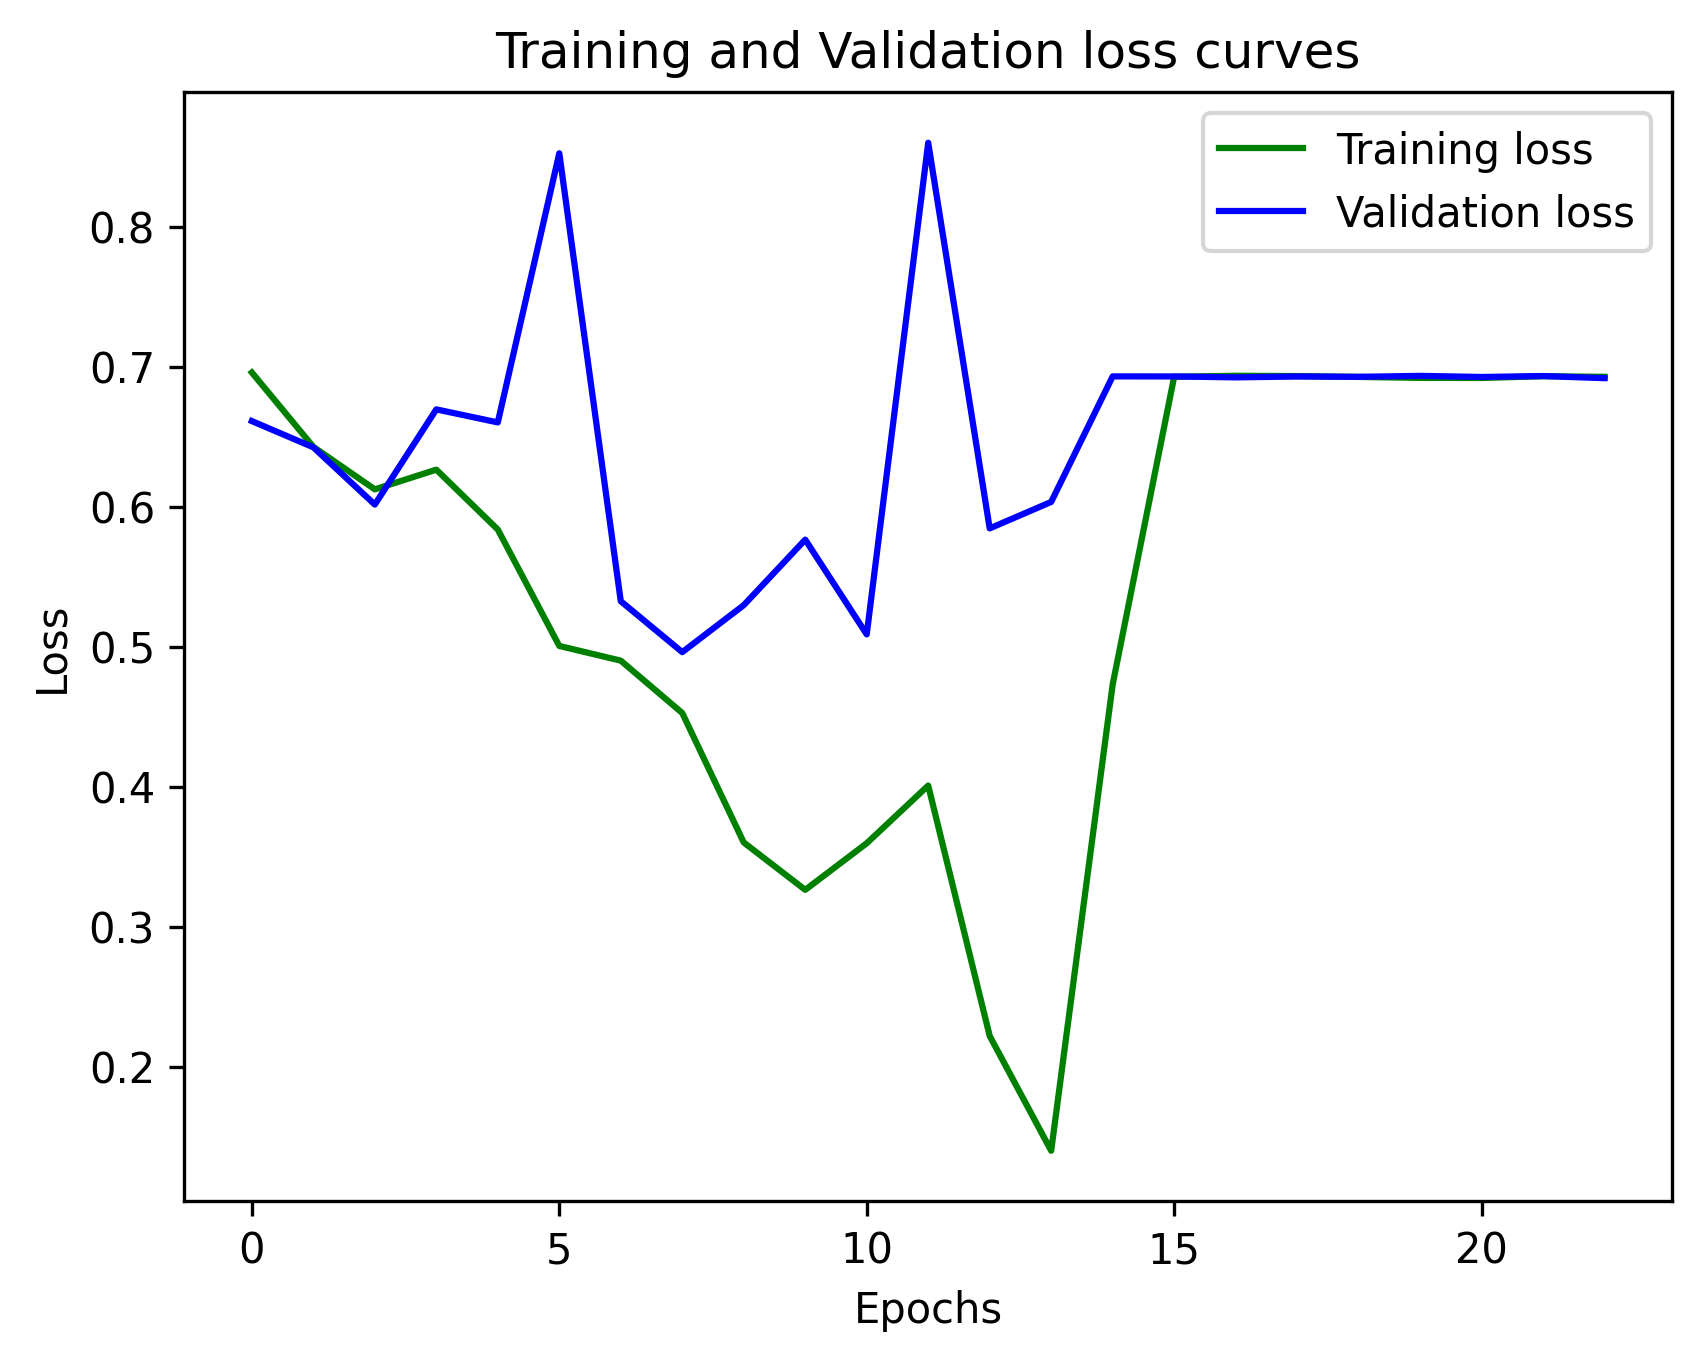

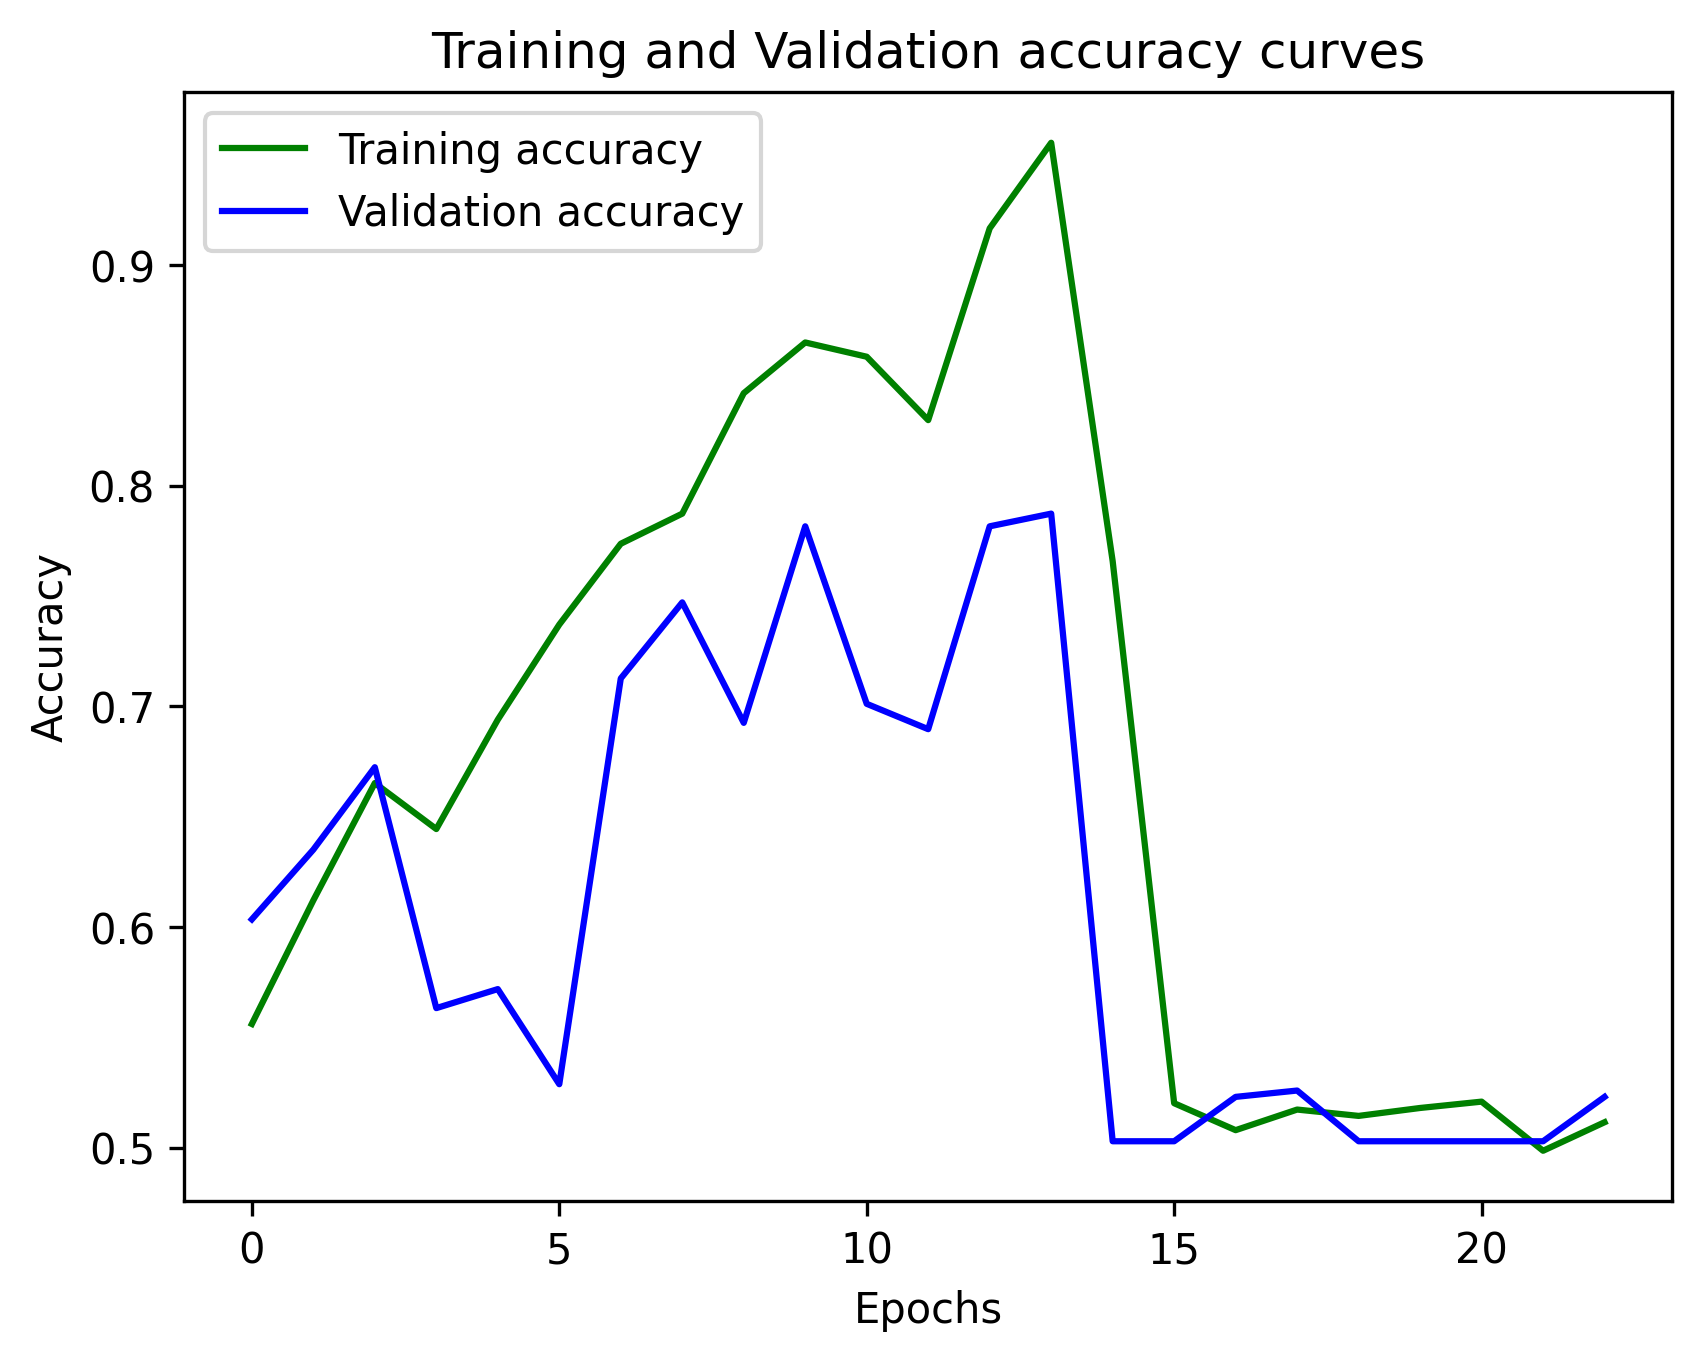

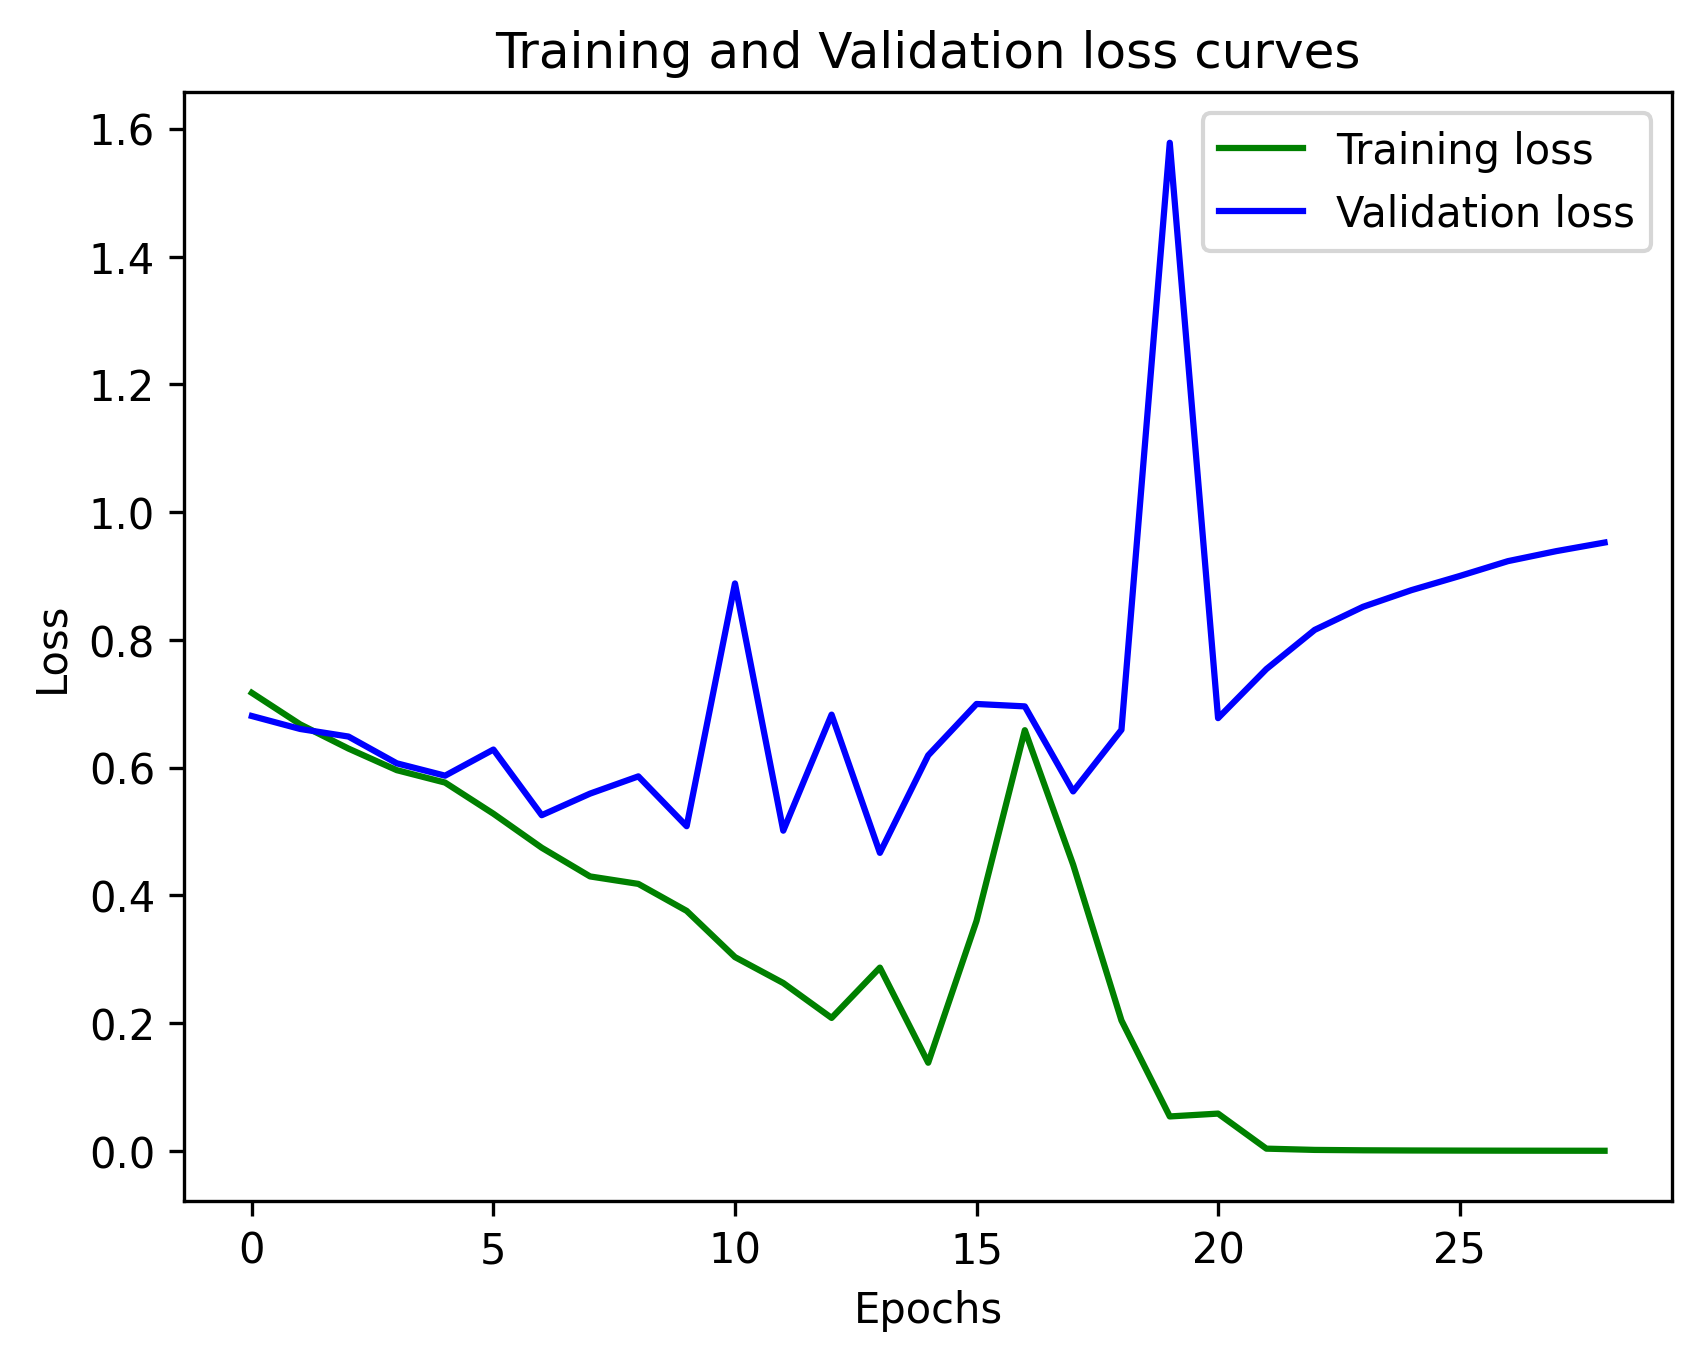

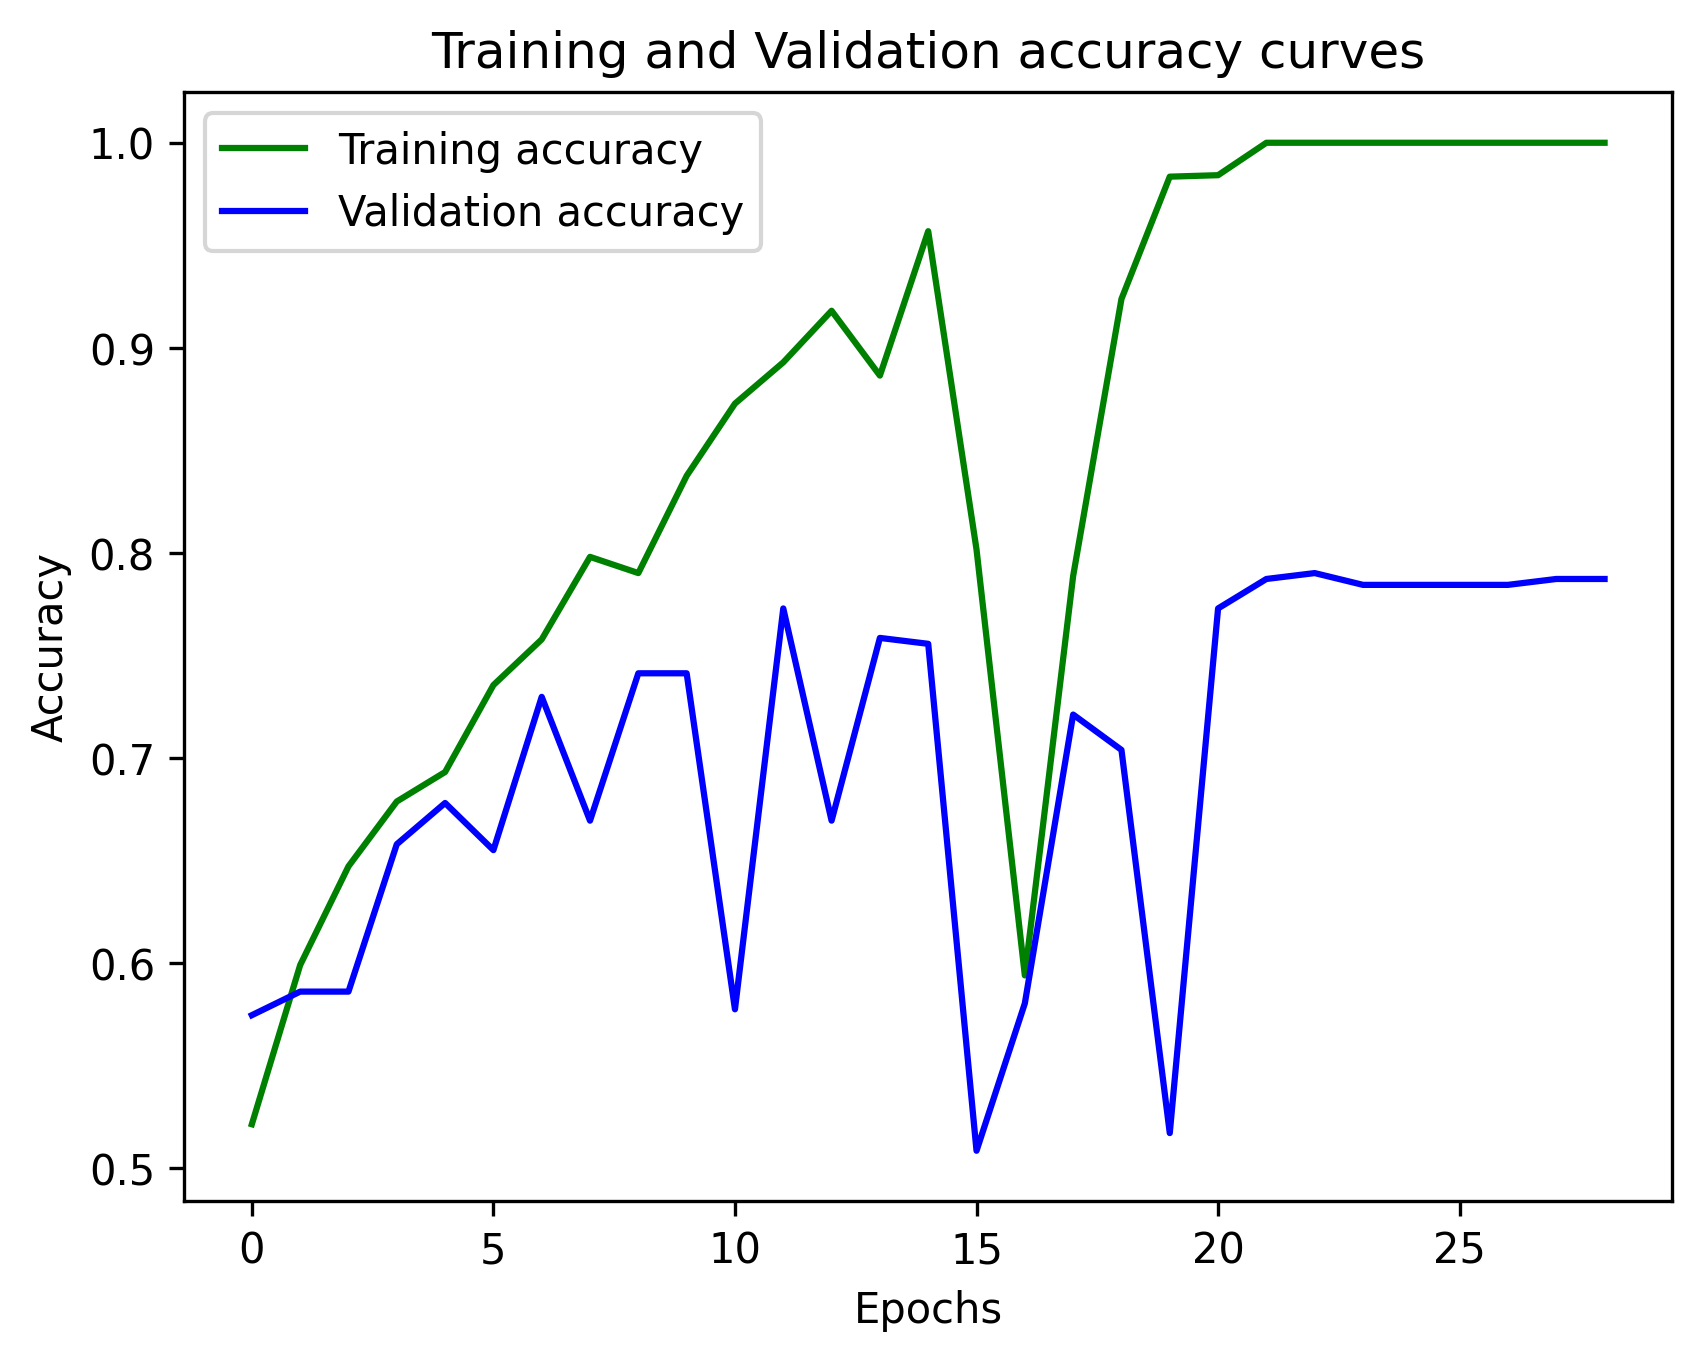

In [29]:
training_times = []

configs = ['Config 0']


print('STATIONS:', subset_name, '\n')
print(' ------------\n|EXPERIMENT 1|\n ------------')

for config in configs:
    
    model_conv         = hyperparameters_dict[config][0]
    freeze             = hyperparameters_dict[config][1]
    top_m              = hyperparameters_dict[config][2]
    neurons_last_layer = hyperparameters_dict[config][3]
    initializer_seed   = hyperparameters_dict[config][4]
    optimizer          = hyperparameters_dict[config][5]
    lr                 = hyperparameters_dict[config][6]
    loss_function      = hyperparameters_dict[config][7]
    activation         = hyperparameters_dict[config][8]
    patience           = hyperparameters_dict[config][9]
    batch_size         = hyperparameters_dict[config][10]
    epochs             = hyperparameters_dict[config][11]
    


    for i in range (k):
        
        fold= i+1
                                            
        a= i
        b= i+1  if i+1 < 5 else i+1-5
        c= i+2  if i+2 < 5 else i+2-5
        d= i+3  if i+3 < 5 else i+3-5
        e= i+4  if i+4 < 5 else i+4-5
    
        print('\n')
        print(f'FOLD {fold}\n--------------\n')
    
        
        # Generate k-fold training and validation sample
        train_paths =  X_y_folds[a][0] + X_y_folds[b][0] + X_y_folds[c][0] + X_y_folds[d][0]
        train_labels = X_y_folds[a][1] + X_y_folds[b][1] + X_y_folds[c][1] + X_y_folds[d][1]
        val_paths =    X_y_folds[e][0]
        val_labels =   X_y_folds[e][1]
    
        train_gen = DataGenerator(image_paths=train_paths, labels=train_labels, batch_size=batch_size, img_size=img_size)
        val_gen   = DataGenerator(image_paths=val_paths,   labels=val_labels,   batch_size=batch_size, img_size=img_size)
    
        model_fold =  f'{fold}'
        

        start = time.time()

        # Train the model
        My_Custom_Model(train_gen, val_gen, img_size,
                        model_conv, freeze, top_m, neurons_last_layer, initializer_seed, optimizer, lr, loss_function, activation,
                        metrics, patience, batch_size, epochs, model_dir, model_fold, print_report, subset).runall()
        end = time.time()
        train_time = end - start
        training_times.append(train_time)

### **6. Summary and Conclusions**

The training process, monitored via 5-fold Stratified Cross-Validation, confirms the successful convergence of the VGG19 model for identifying Calcific Tendinitis. The accuracy and loss metrics recorded in this notebook demonstrate a consistent learning trajectory: a rapid optimization phase during the initial epochs followed by a steady stabilization. The custom Data Generator proved to be a robust solution for handling the dataset, maintaining high computational throughput without compromising the integrity of the image data.

Analysis of the training logs reveals that the model effectively captured the radiological patterns across images from various Canon Inc. workstations. While the training curves show high performance, the validation curves display minor fluctuations and a slight gap typical of medical imaging tasks, indicating a manageable level of overfitting. However, the overall stability across all five folds validates the choice of hyperparameters and confirms that the model is not relying on artifacts from a single data split.

In conclusion, this notebook establishes a high-performance baseline for CTRC diagnosis using Deep Learning. The successful integration of a scalable data loading system and a fine-tuned CNN architecture provides a reliable foundation for the next phase of the project: extracting deep features for hybrid ML models and conducting final prospective testing. These results represent a significant step toward an automated clinical decision support tool for rotator cuff pathologies.